## Simulate the model under recursive least square learning

In [1]:
import numpy as np
import plot_style
import matplotlib.pyplot as plt

plot_style.apply()

In [2]:
# Parameter calibration
a = 1.001 # mean of the dividend process
gamma = 2.0 # risk aversion
sigma = 0.01 # std dev of the dividend process
sigma_x = 0.01 # std dev of the observable variable
delta = 0.96 # discount factor
phi = np.exp(sigma**2 / 2) # correction term for lognormality
kappa = delta * a ** ( - gamma) * phi
w = - np.log(kappa) - np.exp(-10)  # small constant to ensure positivity

## Univariate case

In [3]:
# Initialization
T = 100 # number of time periods
x = np.random.normal(0, sigma_x, T) # observable variable
r = np.zeros(T) # actual gross returns
beta = np.zeros(T) # coefficient for the observable variable
M = np.zeros(T)

#Starting values
beta[0] = np.random.normal(0, 0.001) #small perturbation around REE
beta[1] = np.random.normal(0, 0.001)
M[0] = sigma_x ** 2 # initial variance of the observable variable 
r[1] = np.random.normal(0, 0.0001) 

for t in range(2, T):
    # update M
    M[t-1] = M[t-2] + (x[t-2]**2 - M[t-2]) / (t)
    # update beta using RLS
    beta[t] = beta[t-1] + ((t-1) * M[t-1]) ** -1 * (x[t-2] * r[t-1] - x[t-2]**2 * beta[t-1])
    # compute expected returns
    r[t] = np.log(1 - kappa * np.exp(w * np.tanh(beta[t-1] * x[t-1] / w))) - np.log(1 - kappa * np.exp(w * np.tanh(beta[t] * x[t] / w))) + np.random.normal(0, sigma)


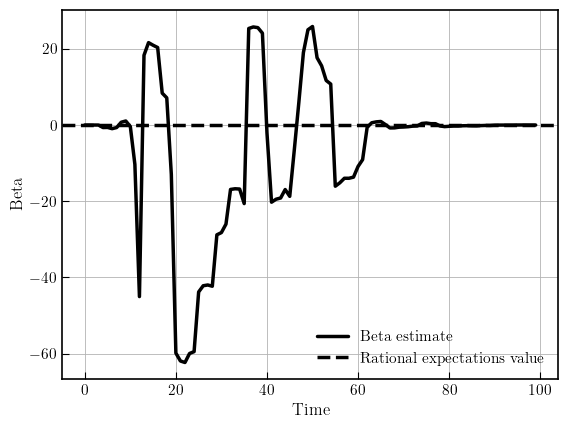

In [4]:
#visualize beta coefficient over time
fig, ax = plt.subplots()
ax.plot(beta, label='Beta estimate')
ax.axhline(0, color='black', linestyle='--', label='Rational expectations value')
ax.set_ylabel('Beta')
ax.set_xlabel('Time')
ax.legend()
plt.show()

## Multivariate case (2 is enough)

In [5]:
def multivariate_RLS(T, K, sigma_x, sigma, kappa, w):
    
    x = np.random.normal(0, sigma_x, (T, K)) # observable variables
    beta = np.zeros((T, K, 1)) # coefficients for the observable variables
    M = np.zeros((T, K, K))

    #Starting values
    beta[0, :, 0] = np.random.normal(0, 0.001, K) #small perturbation around REE
    beta[1, :, 0] = np.random.normal(0, 0.001, K)
    M[0, :, :] = np.eye(K) * sigma_x ** 2 # initial variance of the observable variables 
    r[1] = np.random.normal(0, 0.0001)

    for t in range(2, T):
        # update M
        M[t-1, :, :] = M[t-2, :, :] + (np.outer(x[t-2, :], x[t-2, :]) - M[t-2, :, :]) / (t)
        # update beta using RLS
        beta[t, :, 0] = beta[t-1, :, 0] + np.linalg.inv((t-1) * M[t-1, :, :]) @ (x[t-2, :].reshape(-1, 1) * r[t-1] - (x[t-2, :].reshape(-1, 1) @ x[t-2, :].reshape(1, -1)) @ beta[t-1, :, 0].reshape(-1, 1)).flatten()
        # compute expected returns
        r[t] = np.log(1 - kappa * np.exp(w * np.tanh((beta[t-1, :, 0] @ x[t-1, :].reshape(-1, 1)) / w))) - np.log(1 - kappa * np.exp(w * np.tanh((beta[t, :, 0] @ x[t, :].reshape(-1, 1)) / w))) + np.random.normal(0, sigma)
    return beta, r

In [6]:
beta, r = multivariate_RLS(T=100, K=2, sigma_x=sigma_x, sigma=sigma, kappa=kappa, w=w)

/var/folders/hb/bc0srnt52zx6lbw4t2k_t_k80000gn/T/ipykernel_58116/1209086053.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r[t] = np.log(1 - kappa * np.exp(w * np.tanh((beta[t-1, :, 0] @ x[t-1, :].reshape(-1, 1)) / w))) - np.log(1 - kappa * np.exp(w * np.tanh((beta[t, :, 0] @ x[t, :].reshape(-1, 1)) / w))) + np.random.normal(0, sigma)


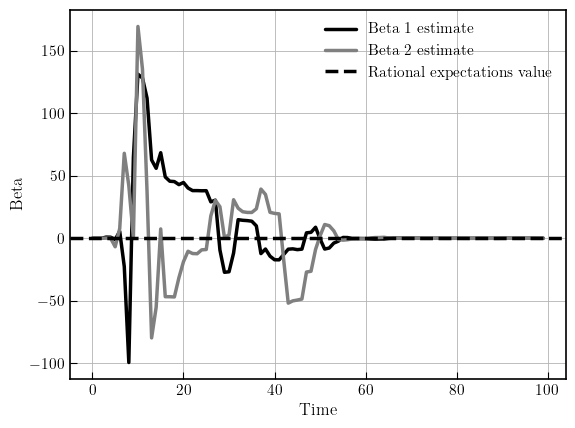

In [7]:
#visualzie the two betas over time
fig, ax = plt.subplots()
ax.plot(beta[:, 0, 0], label='Beta 1 estimate')
ax.plot(beta[:, 1, 0], label='Beta 2 estimate', color = 'gray')
ax.axhline(0, color='black', linestyle='--', label='Rational expectations value')
ax.set_ylabel('Beta')
ax.set_xlabel('Time')
ax.legend()
plt.show()

In [8]:
## Check with multiple stochastic seeds to ensure robustness
num_simulations = 10
all_betas = []
for sim in range(num_simulations):
    np.random.seed(sim)
    beta, r = multivariate_RLS(T=100, K=2, sigma_x=sigma_x, sigma=sigma, kappa=kappa, w=w)
    all_betas.append(beta)

/var/folders/hb/bc0srnt52zx6lbw4t2k_t_k80000gn/T/ipykernel_58116/1209086053.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r[t] = np.log(1 - kappa * np.exp(w * np.tanh((beta[t-1, :, 0] @ x[t-1, :].reshape(-1, 1)) / w))) - np.log(1 - kappa * np.exp(w * np.tanh((beta[t, :, 0] @ x[t, :].reshape(-1, 1)) / w))) + np.random.normal(0, sigma)


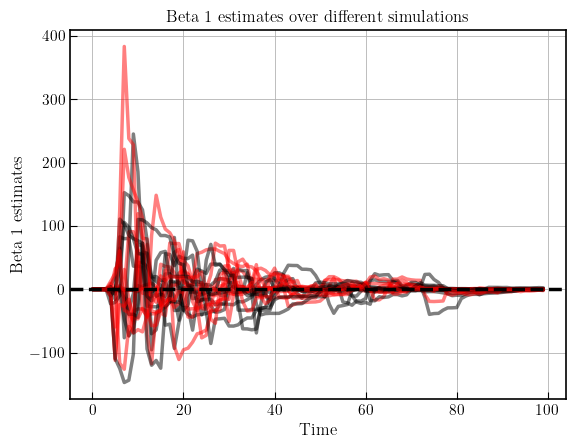

In [9]:
#visualization of coefficients over seeds
fig, ax = plt.subplots()
for sim in range(num_simulations):
    ax.plot(all_betas[sim][:, 0, 0], alpha=0.5, label = 'beta_1')
    ax.plot(all_betas[sim][:, 1, 0], alpha=0.5, color = 'red', label = 'beta_2')
ax.axhline(0, color='black', linestyle='--', label='Rational expectations value')
ax.set_ylabel('Beta 1 estimates')
ax.set_xlabel('Time')
ax.set_title('Beta 1 estimates over different simulations')
plt.show()